# Baseline Weighted CNN

- 3 convolutional blocks:
    - Conv2D → ReLU → MaxPooling
- Channel progression: 3 → 32 → 64 → 128

**Objective** <br/>
Evaluate whether class-weighted BCE loss improves melanoma detection under class imbalance.

**Changes from baseline** <br/>
- Added pos_weight to BCEWithLogitsLoss
- Kept CNN architecture unchanged

**Hypothesis** <br/>
Weighting the minority melanoma class will improve melanoma recall.

### 1. Import libraries

In [1]:
import sys
import os
from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from src.data.dataloader import get_dataloaders
from src.models.cnn_baseline import SimpleCNN
from src.training.trainer import train_one_epoch, validate_one_epoch


from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

os.chdir(ROOT)
print(Path.cwd())

/Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning


### 2. Use Cuda else MPS

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: mps


### 3. Split Dataset 
- Use simpleCNN model
- Use BCEWithLogitsLoss
- Use Adam optimizer

In [3]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv("data_new/splits/train.csv")

num_melanoma = (train_df["label"] == 1).sum()  # CSV melanoma
num_nevus = (train_df["label"] == 0).sum()     # CSV nevus

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print("pos_weight:", pos_weight)

model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

pos_weight: tensor([8.1117], device='mps:0')


### 4. Train Model

In [4]:
best_val_loss = float("inf")

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}"
    )

    # Save best model
    # if val_metrics["loss"] < best_val_loss:
    #     best_val_loss = val_metrics["loss"]
    #     torch.save(model.state_dict(), "models/cnn_baseline.pth")
    #     print("Saved best model at epoch", epoch+1)

Epoch [1/20] | Train Loss: 1.1402, Train Acc: 0.5704 | Val Loss: 0.9699, Val Acc: 0.5292


Epoch [2/20] | Train Loss: 1.0699, Train Acc: 0.6183 | Val Loss: 0.9578, Val Acc: 0.6107


Epoch [3/20] | Train Loss: 0.9687, Train Acc: 0.6322 | Val Loss: 0.9221, Val Acc: 0.5366


Epoch [4/20] | Train Loss: 0.9279, Train Acc: 0.6642 | Val Loss: 0.9186, Val Acc: 0.5499


Epoch [5/20] | Train Loss: 1.0094, Train Acc: 0.5975 | Val Loss: 0.9146, Val Acc: 0.6136


...

Epoch [16/20] | Train Loss: 0.7762, Train Acc: 0.7296 | Val Loss: 0.8655, Val Acc: 0.7223


Epoch [17/20] | Train Loss: 0.7689, Train Acc: 0.7433 | Val Loss: 0.9367, Val Acc: 0.7762


Epoch [18/20] | Train Loss: 0.8104, Train Acc: 0.7408 | Val Loss: 1.1208, Val Acc: 0.6151


Epoch [19/20] | Train Loss: 0.8518, Train Acc: 0.7277 | Val Loss: 0.9661, Val Acc: 0.6877


Epoch [20/20] | Train Loss: 0.8253, Train Acc: 0.7411 | Val Loss: 0.8938, Val Acc: 0.7204


### 5. Plot Loss and Accuracy Curves

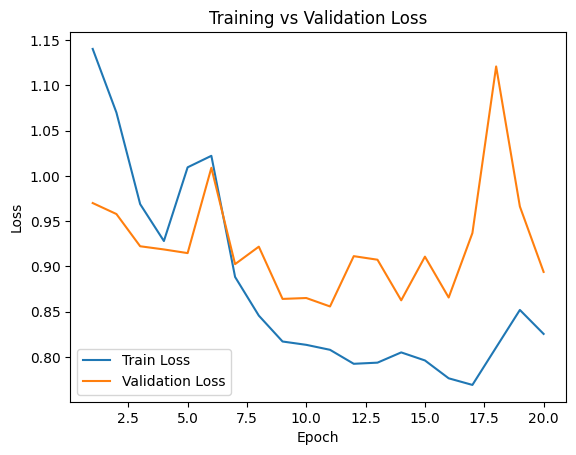

In [5]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

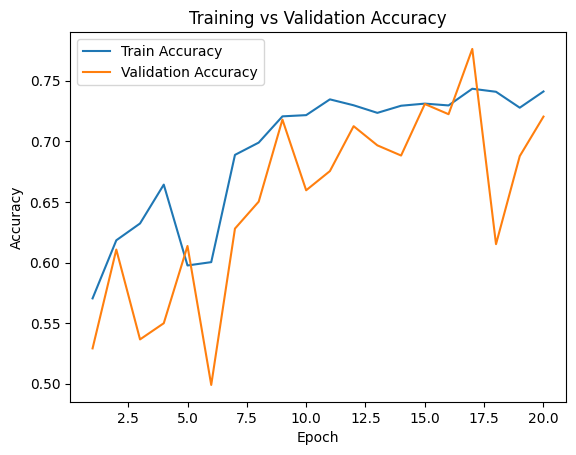

In [6]:
plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### 6. Evaluate model
[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

Precision → “When the model says YES, how often is it correct?” <br/>
Recall → “Out of all actual YES, how many did we catch?”

In [7]:
from sklearn.metrics import f1_score, precision_score, recall_score, balanced_accuracy_score
import numpy as np

model.eval()

val_labels = []
val_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)

        val_labels.extend(labels.numpy())
        val_probs.extend(probs.cpu().numpy())

thresholds = np.arange(0.05, 0.95, 0.05)

best_threshold = 0.5
best_f1 = -1

for threshold in thresholds:
    preds = [1 if p >= threshold else 0 for p in val_probs]
    f1 = f1_score(val_labels, preds)

    print(
        f"Threshold={threshold:.2f} | "
        f"F1={f1:.4f} | "
        f"Precision={precision_score(val_labels, preds):.4f} | "
        f"Recall={recall_score(val_labels, preds):.4f} | "
        f"Balanced Acc={balanced_accuracy_score(val_labels, preds):.4f}"
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\nBest threshold on validation set: {best_threshold:.2f}")


Threshold=0.05 | F1=0.3144 | Precision=0.1870 | Recall=0.9873 | Balanced Acc=0.7104
Threshold=0.10 | F1=0.3244 | Precision=0.1946 | Recall=0.9746 | Balanced Acc=0.7211
Threshold=0.15 | F1=0.3319 | Precision=0.2009 | Recall=0.9534 | Balanced Acc=0.7264
Threshold=0.20 | F1=0.3410 | Precision=0.2080 | Recall=0.9449 | Balanced Acc=0.7350
Threshold=0.25 | F1=0.3456 | Precision=0.2122 | Recall=0.9322 | Balanced Acc=0.7376
Threshold=0.30 | F1=0.3495 | Precision=0.2160 | Recall=0.9153 | Balanced Acc=0.7384
Threshold=0.35 | F1=0.3600 | Precision=0.2246 | Recall=0.9068 | Balanced Acc=0.7467
Threshold=0.40 | F1=0.3749 | Precision=0.2369 | Recall=0.8983 | Balanced Acc=0.7582
Threshold=0.45 | F1=0.3837 | Precision=0.2456 | Recall=0.8771 | Balanced Acc=0.7607
Threshold=0.50 | F1=0.4092 | Precision=0.2715 | Recall=0.8305 | Balanced Acc=0.7682
Threshold=0.55 | F1=0.4223 | Precision=0.2907 | Recall=0.7712 | Balanced Acc=0.7614
Threshold=0.60 | F1=0.4291 | Precision=0.3121 | Recall=0.6864 | Balanced Acc

In [8]:
model.eval()

all_labels = []
all_probs = []
all_preds = []

threshold = best_threshold

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)                      # raw logits
        probs = torch.sigmoid(outputs).squeeze(1)    # probabilities
        preds = (probs >= threshold).long()             # binary predictions

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [9]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

print(classification_report(all_labels, all_preds, digits=4))

Confusion Matrix:
[[1160  180]
 [  65  106]]
              precision    recall  f1-score   support

           0     0.9469    0.8657    0.9045      1340
           1     0.3706    0.6199    0.4639       171

    accuracy                         0.8379      1511
   macro avg     0.6588    0.7428    0.6842      1511
weighted avg     0.8817    0.8379    0.8546      1511



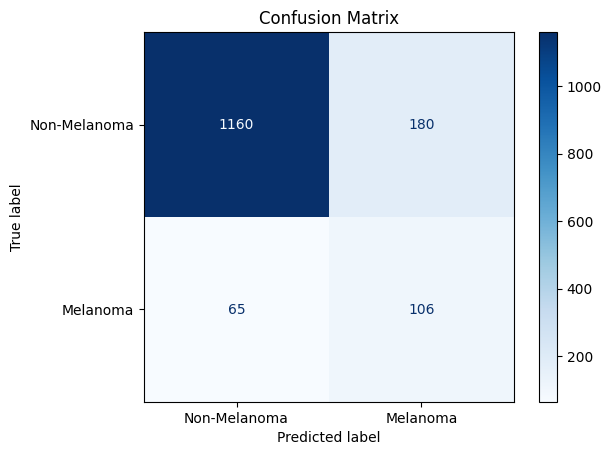

In [10]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Melanoma", "Melanoma"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

- The weighted CNN baseline improves minority-class detection by introducing a positive-class weight in the loss function and selecting a better classification threshold on the validation set. 
- Compared with the unweighted baseline, melanoma recall increases substantially from 28.07% to 61.99%, while melanoma F1-score also improves from 0.3556 to 0.4639. Although overall accuracy decreases from 88.48% to 83.79%, the weighted model is more effective at identifying melanoma cases, which is more important for this task. 
- From the training curves, the model does not show severe overfitting, since the gap between training and validation performance is not large. 
- Instead, both training and validation metrics remain relatively modest and unstable, suggesting that the model is still somewhat underfitting and that the simple CNN architecture may be too limited to capture the full complexity of the dataset.